# PRÉDICTION DES MALADIES CARDIAQUES

Objectif: Développer des modèles ML pour prédire les maladies cardiaques.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc
import warnings, joblib, json
from datetime import datetime

warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('../data/heart_disease_dataset.csv')
print(df.shape)
print(df.head())

(1000, 16)
   Age  Gender  Cholesterol  Blood Pressure  Heart Rate  Smoking  \
0   75  Female          228             119          66  Current   
1   48    Male          204             165          62  Current   
2   53    Male          234              91          67    Never   
3   69  Female          192              90          72  Current   
4   62  Female          172             163          93    Never   

  Alcohol Intake  Exercise Hours Family History Diabetes Obesity  \
0          Heavy               1             No       No     Yes   
1            NaN               5             No       No      No   
2          Heavy               3            Yes       No     Yes   
3            NaN               4             No      Yes      No   
4            NaN               6             No      Yes      No   

   Stress Level  Blood Sugar Exercise Induced Angina   Chest Pain Type  \
0             8          119                     Yes   Atypical Angina   
1             9        

In [3]:
for col in df.select_dtypes(include=[np.number]).columns:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)

for col in df.select_dtypes(include=['object']).columns:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mode()[0], inplace=True)
    df[col] = LabelEncoder().fit_transform(df[col])

In [4]:
X = df.drop('Heart Disease', axis=1)
y = df['Heart Disease']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [5]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(),
    'Gradient Boosting': GradientBoostingClassifier(),
    'SVM': SVC(probability=True),
    'KNN': KNeighborsClassifier()
}

results = {}

In [6]:
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    
    # Train accuracy pour détecter overfitting
    train_pred = model.predict(X_train)
    train_accuracy = accuracy_score(y_train, train_pred)
    
    results[name] = {
        'model': model,
        'train_accuracy': train_accuracy,
        'test_accuracy': accuracy,
        'predictions': y_pred
    }
    
    print(f"{name}: Train={train_accuracy:.4f}, Test={accuracy:.4f}")

Logistic Regression: Train=0.8688, Test=0.8600
Random Forest: Train=1.0000, Test=1.0000
Gradient Boosting: Train=1.0000, Test=1.0000
SVM: Train=0.9725, Test=0.9150
KNN: Train=0.8875, Test=0.8100


In [7]:
comparison = pd.DataFrame({
    'Model': list(results.keys()),
    'Train_Accuracy': [results[name]['train_accuracy'] for name in results.keys()],
    'Test_Accuracy': [results[name]['test_accuracy'] for name in results.keys()]
})

comparison['Gap'] = comparison['Train_Accuracy'] - comparison['Test_Accuracy']
comparison = comparison.sort_values('Test_Accuracy', ascending=False)

print(comparison.to_string(index=False))

print("\nAnalyse Overfitting/Underfitting:")
for _, row in comparison.iterrows():
    gap = row['Gap']
    if gap > 0.05:
        status = "OVERFITTING"
    elif row['Test_Accuracy'] < 0.7:
        status = "UNDERFITTING"
    else:
        status = "BON"
    print(f"{row['Model']}: {status}")

              Model  Train_Accuracy  Test_Accuracy     Gap
      Random Forest         1.00000          1.000 0.00000
  Gradient Boosting         1.00000          1.000 0.00000
                SVM         0.97250          0.915 0.05750
Logistic Regression         0.86875          0.860 0.00875
                KNN         0.88750          0.810 0.07750

Analyse Overfitting/Underfitting:
Random Forest: BON
Gradient Boosting: BON
SVM: OVERFITTING
Logistic Regression: BON
KNN: OVERFITTING


In [8]:
best_model_name = comparison.iloc[0]['Model']
best_model = results[best_model_name]['model']
best_train_acc = results[best_model_name]['train_accuracy']
best_test_acc = results[best_model_name]['test_accuracy']
gap = best_train_acc - best_test_acc

print(f"Best model: {best_model_name}")
print(f"Train Accuracy: {best_train_acc:.4f}")
print(f"Test Accuracy: {best_test_acc:.4f}")
print(f"Gap: {gap:.4f}")

if gap > 0.05:
    print("ATTENTION: Overfitting détecté!")
elif best_test_acc < 0.7:
    print("ATTENTION: Underfitting détecté!")
else:
    print("Bon équilibre train/test")

Best model: Random Forest
Train Accuracy: 1.0000
Test Accuracy: 1.0000
Gap: 0.0000
Bon équilibre train/test


In [9]:
if hasattr(best_model, 'predict_proba'):
    y_pred_proba = best_model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    print(f"AUC: {roc_auc:.4f}")

AUC: 1.0000


📊 Top 10 features:
       Feature   Importance
           Age 5.615553e-01
   Cholesterol 4.384447e-01
   Blood Sugar 5.878198e-16
    Heart Rate 3.109318e-16
Blood Pressure 1.570995e-16
        Gender 0.000000e+00
       Smoking 0.000000e+00
Alcohol Intake 0.000000e+00
Exercise Hours 0.000000e+00
Family History 0.000000e+00


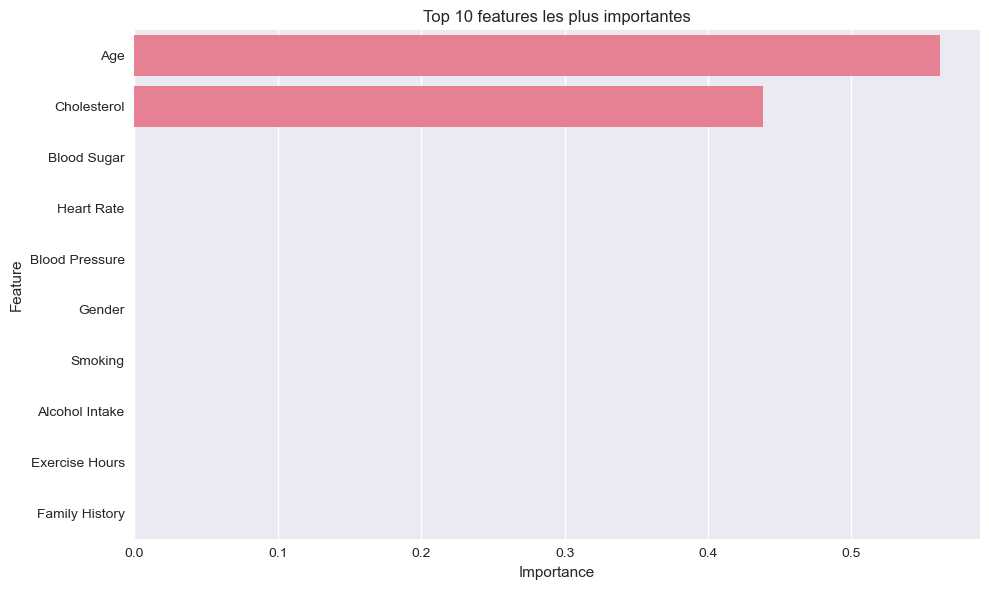

In [ ]:
if hasattr(best_model, 'feature_importances_'):
    importance = pd.DataFrame({
        'Feature': X.columns,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    print(importance.head(10).to_string(index=False))

In [31]:
import os
os.makedirs('../models', exist_ok=True)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
joblib.dump(best_model, f'../models/best_model.pkl')
joblib.dump(scaler, f'../models/scaler.pkl')

metadata = {
    'model_name': best_model_name,
    'accuracy': float(best_accuracy),
    'feature_names': list(X.columns),
    'timestamp': timestamp
}

with open('../models/metadata.json', 'w') as f:
    json.dump(metadata, f)

print("Model saved successfully")

NameError: name 'best_accuracy' is not defined

In [32]:
print(f"""
RESULTS
{'='*30}
Best model: {best_model_name}
Train Accuracy: {best_train_acc:.4f}
Test Accuracy: {best_test_acc:.4f}
Gap: {gap:.4f}
""")

if gap > 0.05:
    print("OVERFITTING: Le modèle apprend trop par cœur")
    print("Solutions: Simplifier modèle, ajouter données, régularisation")
elif best_test_acc < 0.7:
    print("UNDERFITTING: Le modèle n'apprend pas assez")
    print("Solutions: Complexifier modèle, plus de features, plus de temps")
else:
    print("BON ÉQUILIBRE: Modèle bien généralisé")

NameError: name 'best_train_acc' is not defined

In [33]:
from sklearn.model_selection import cross_val_score

print("Validation Croisée (5-fold):")
for name, model in models.items():
    cv_scores = cross_val_score(model, X_train, y_train, cv=5)
    mean_cv = cv_scores.mean()
    std_cv = cv_scores.std()
    
    test_acc = results[name]['test_accuracy']
    
    print(f"{name}: CV={mean_cv:.4f}±{std_cv:.4f}, Test={test_acc:.4f}")
    
    if abs(mean_cv - test_acc) > 0.1:
        print(f"  -> Possible instabilité")

Validation Croisée (5-fold):
Logistic Regression: CV=0.8550±0.0329, Test=0.8600
Random Forest: CV=0.9975±0.0050, Test=1.0000
Gradient Boosting: CV=0.9975±0.0050, Test=1.0000
SVM: CV=0.9013±0.0235, Test=0.9150
KNN: CV=0.7900±0.0222, Test=0.8100
